In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor #variable selection
import sys
from statsmodels.stats.stattools import durbin_watson


In [2]:
print(sys.version)

3.12.5 (v3.12.5:ff3bc82f7c9, Aug  7 2024, 05:32:06) [Clang 13.0.0 (clang-1300.0.29.30)]


# Import the Dataset

In [3]:
df = pd.read_csv('D600 Task 1 Dataset_1_Housing_Information.csv')
pd.set_option('display.max_columns', None)

df.head()

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,97.29,1.84,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,93.22,0.95,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,96.60,1.87,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,91.45,1.45,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,86.50,1.26,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0


##### Drop ID Column

In [4]:
df = df.drop(columns=['ID'])

# Describe Variables

Convert variables to categorical data type

In [5]:
df['IsLuxury'] = df['IsLuxury'].astype('category')


#### Dependent Variable

In [6]:
df['Price'].describe()

count    7.000000e+03
mean     3.072820e+05
std      1.501734e+05
min      8.500000e+04
25%      1.921075e+05
50%      2.793230e+05
75%      3.918781e+05
max      1.046676e+06
Name: Price, dtype: float64

In [7]:
df['Price'].mode()

0       8.500000e+04
1       8.623883e+04
2       8.625022e+04
3       8.755343e+04
4       8.759270e+04
            ...     
6995    1.004324e+06
6996    1.021383e+06
6997    1.024519e+06
6998    1.045707e+06
6999    1.046676e+06
Name: Price, Length: 7000, dtype: float64

#### Independent Variables

In [8]:
df_ind = df.drop(columns=['Price'])

In [9]:
df_ind.describe()

,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,Floors,Windows,PreviousSalePrice
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.00000,7000.000000,7.000000e+03
mean,1048.947459,2.131397,3.008571,511.507029,31.226194,6.942923,46.797046,17.475337,93.711349,1.500437,5.003357,5.934579,5.983860,1.16300,16.248857,2.845094e+05
std,426.010482,0.952561,1.021940,279.926549,18.025327,1.888148,31.779701,12.024985,4.505359,0.498591,1.970428,2.657930,1.953974,0.37209,8.926479,1.857340e+05
min,550.000000,1.000000,1.000000,0.390000,0.030000,0.220000,0.010000,0.000000,72.050000,0.010000,0.010000,0.000000,0.010000,1.00000,-6.000000,-8.356902e+03
25%,660.815000,1.290539,2.000000,300.995000,17.390000,5.650000,20.755000,7.827500,90.620000,1.160000,3.660000,4.000000,4.680000,1.00000,11.000000,1.420140e+05
50%,996.320000,1.997774,3.000000,495.965000,30.385000,7.010000,42.620000,15.625000,94.010000,1.490000,5.020000,6.040000,6.000000,1.00000,15.000000,2.621831e+05
75%,1342.292500,2.763997,4.000000,704.012500,43.670000,8.360000,67.232500,25.222500,97.410000,1.840000,6.350000,8.050000,7.350000,1.00000,20.000000,3.961212e+05
max,2874.700000,5.807239,7.000000,1631.360000,99.730000,10.000000,178.680000,65.200000,99.900000,3.360000,10.000000,10.000000,10.000000,3.00000,63.000000,1.296607e+06


##### Mode:

In [10]:
print(df_ind.mode().iloc[0])

SquareFootage                 550.0
NumBathrooms                    1.0
NumBedrooms                     3.0
BackyardSpace                300.08
CrimeRate                     34.01
SchoolRating                   10.0
AgeOfHome                     18.18
DistanceToCityCenter           8.29
EmploymentRate                 99.9
PropertyTaxRate                1.43
RenovationQuality              10.0
LocalAmenities                 10.0
TransportAccess                10.0
Fireplace                        No
HouseColor                    White
Garage                           No
Floors                          1.0
Windows                        14.0
PreviousSalePrice      -8356.902464
IsLuxury                          1
Name: 0, dtype: object


In [11]:
df_cat = df.select_dtypes(exclude = 'number')

In [12]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Fireplace   7000 non-null   object  
 1   HouseColor  7000 non-null   object  
 2   Garage      7000 non-null   object  
 3   IsLuxury    7000 non-null   category
dtypes: category(1), object(3)
memory usage: 171.1+ KB


In [13]:
df_cat.Fireplace.value_counts()

Fireplace
No     5172
Yes    1828
Name: count, dtype: int64

In [14]:
df_cat.HouseColor.value_counts()

HouseColor
White     1446
Yellow    1423
Blue      1409
Green     1375
Red       1347
Name: count, dtype: int64

In [15]:
df_cat.Garage.value_counts()

Garage
No     4488
Yes    2512
Name: count, dtype: int64

In [16]:
df_cat.IsLuxury.value_counts()

IsLuxury
1    3528
0    3472
Name: count, dtype: int64

# Univariate Distribution

Text(0.5, 1.0, 'Histogram of House Prices')

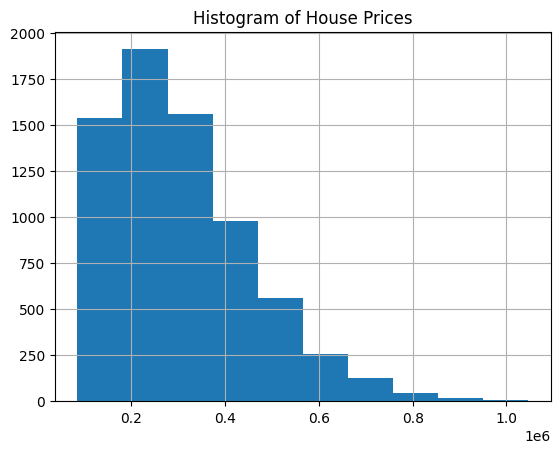

In [17]:
df.Price.hist()
plt.title("Histogram of House Prices")

array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'SquareFootage'}>,
        <Axes: title={'center': 'NumBathrooms'}>,
        <Axes: title={'center': 'NumBedrooms'}>],
       [<Axes: title={'center': 'BackyardSpace'}>,
        <Axes: title={'center': 'CrimeRate'}>,
        <Axes: title={'center': 'SchoolRating'}>,
        <Axes: title={'center': 'AgeOfHome'}>],
       [<Axes: title={'center': 'DistanceToCityCenter'}>,
        <Axes: title={'center': 'EmploymentRate'}>,
        <Axes: title={'center': 'PropertyTaxRate'}>,
        <Axes: title={'center': 'RenovationQuality'}>],
       [<Axes: title={'center': 'LocalAmenities'}>,
        <Axes: title={'center': 'TransportAccess'}>,
        <Axes: title={'center': 'Floors'}>,
        <Axes: title={'center': 'Windows'}>],
       [<Axes: title={'center': 'PreviousSalePrice'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

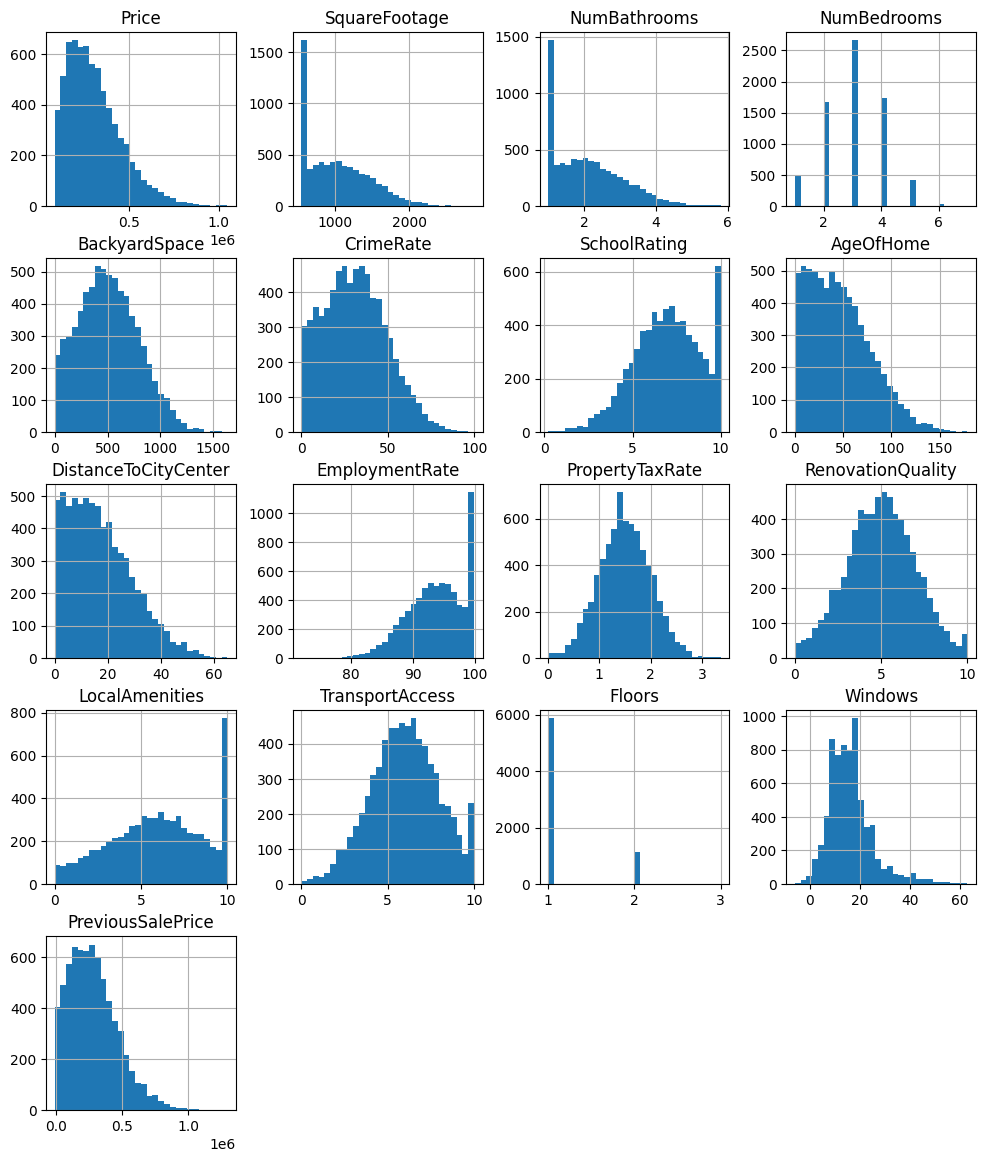

In [18]:
df.hist(figsize=(12,14), bins=30)

# Bivariate Visualizations

In [19]:
df_num = df_ind.select_dtypes(include='number')
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SquareFootage         7000 non-null   float64
 1   NumBathrooms          7000 non-null   float64
 2   NumBedrooms           7000 non-null   int64  
 3   BackyardSpace         7000 non-null   float64
 4   CrimeRate             7000 non-null   float64
 5   SchoolRating          7000 non-null   float64
 6   AgeOfHome             7000 non-null   float64
 7   DistanceToCityCenter  7000 non-null   float64
 8   EmploymentRate        7000 non-null   float64
 9   PropertyTaxRate       7000 non-null   float64
 10  RenovationQuality     7000 non-null   float64
 11  LocalAmenities        7000 non-null   float64
 12  TransportAccess       7000 non-null   float64
 13  Floors                7000 non-null   int64  
 14  Windows               7000 non-null   int64  
 15  PreviousSalePrice    

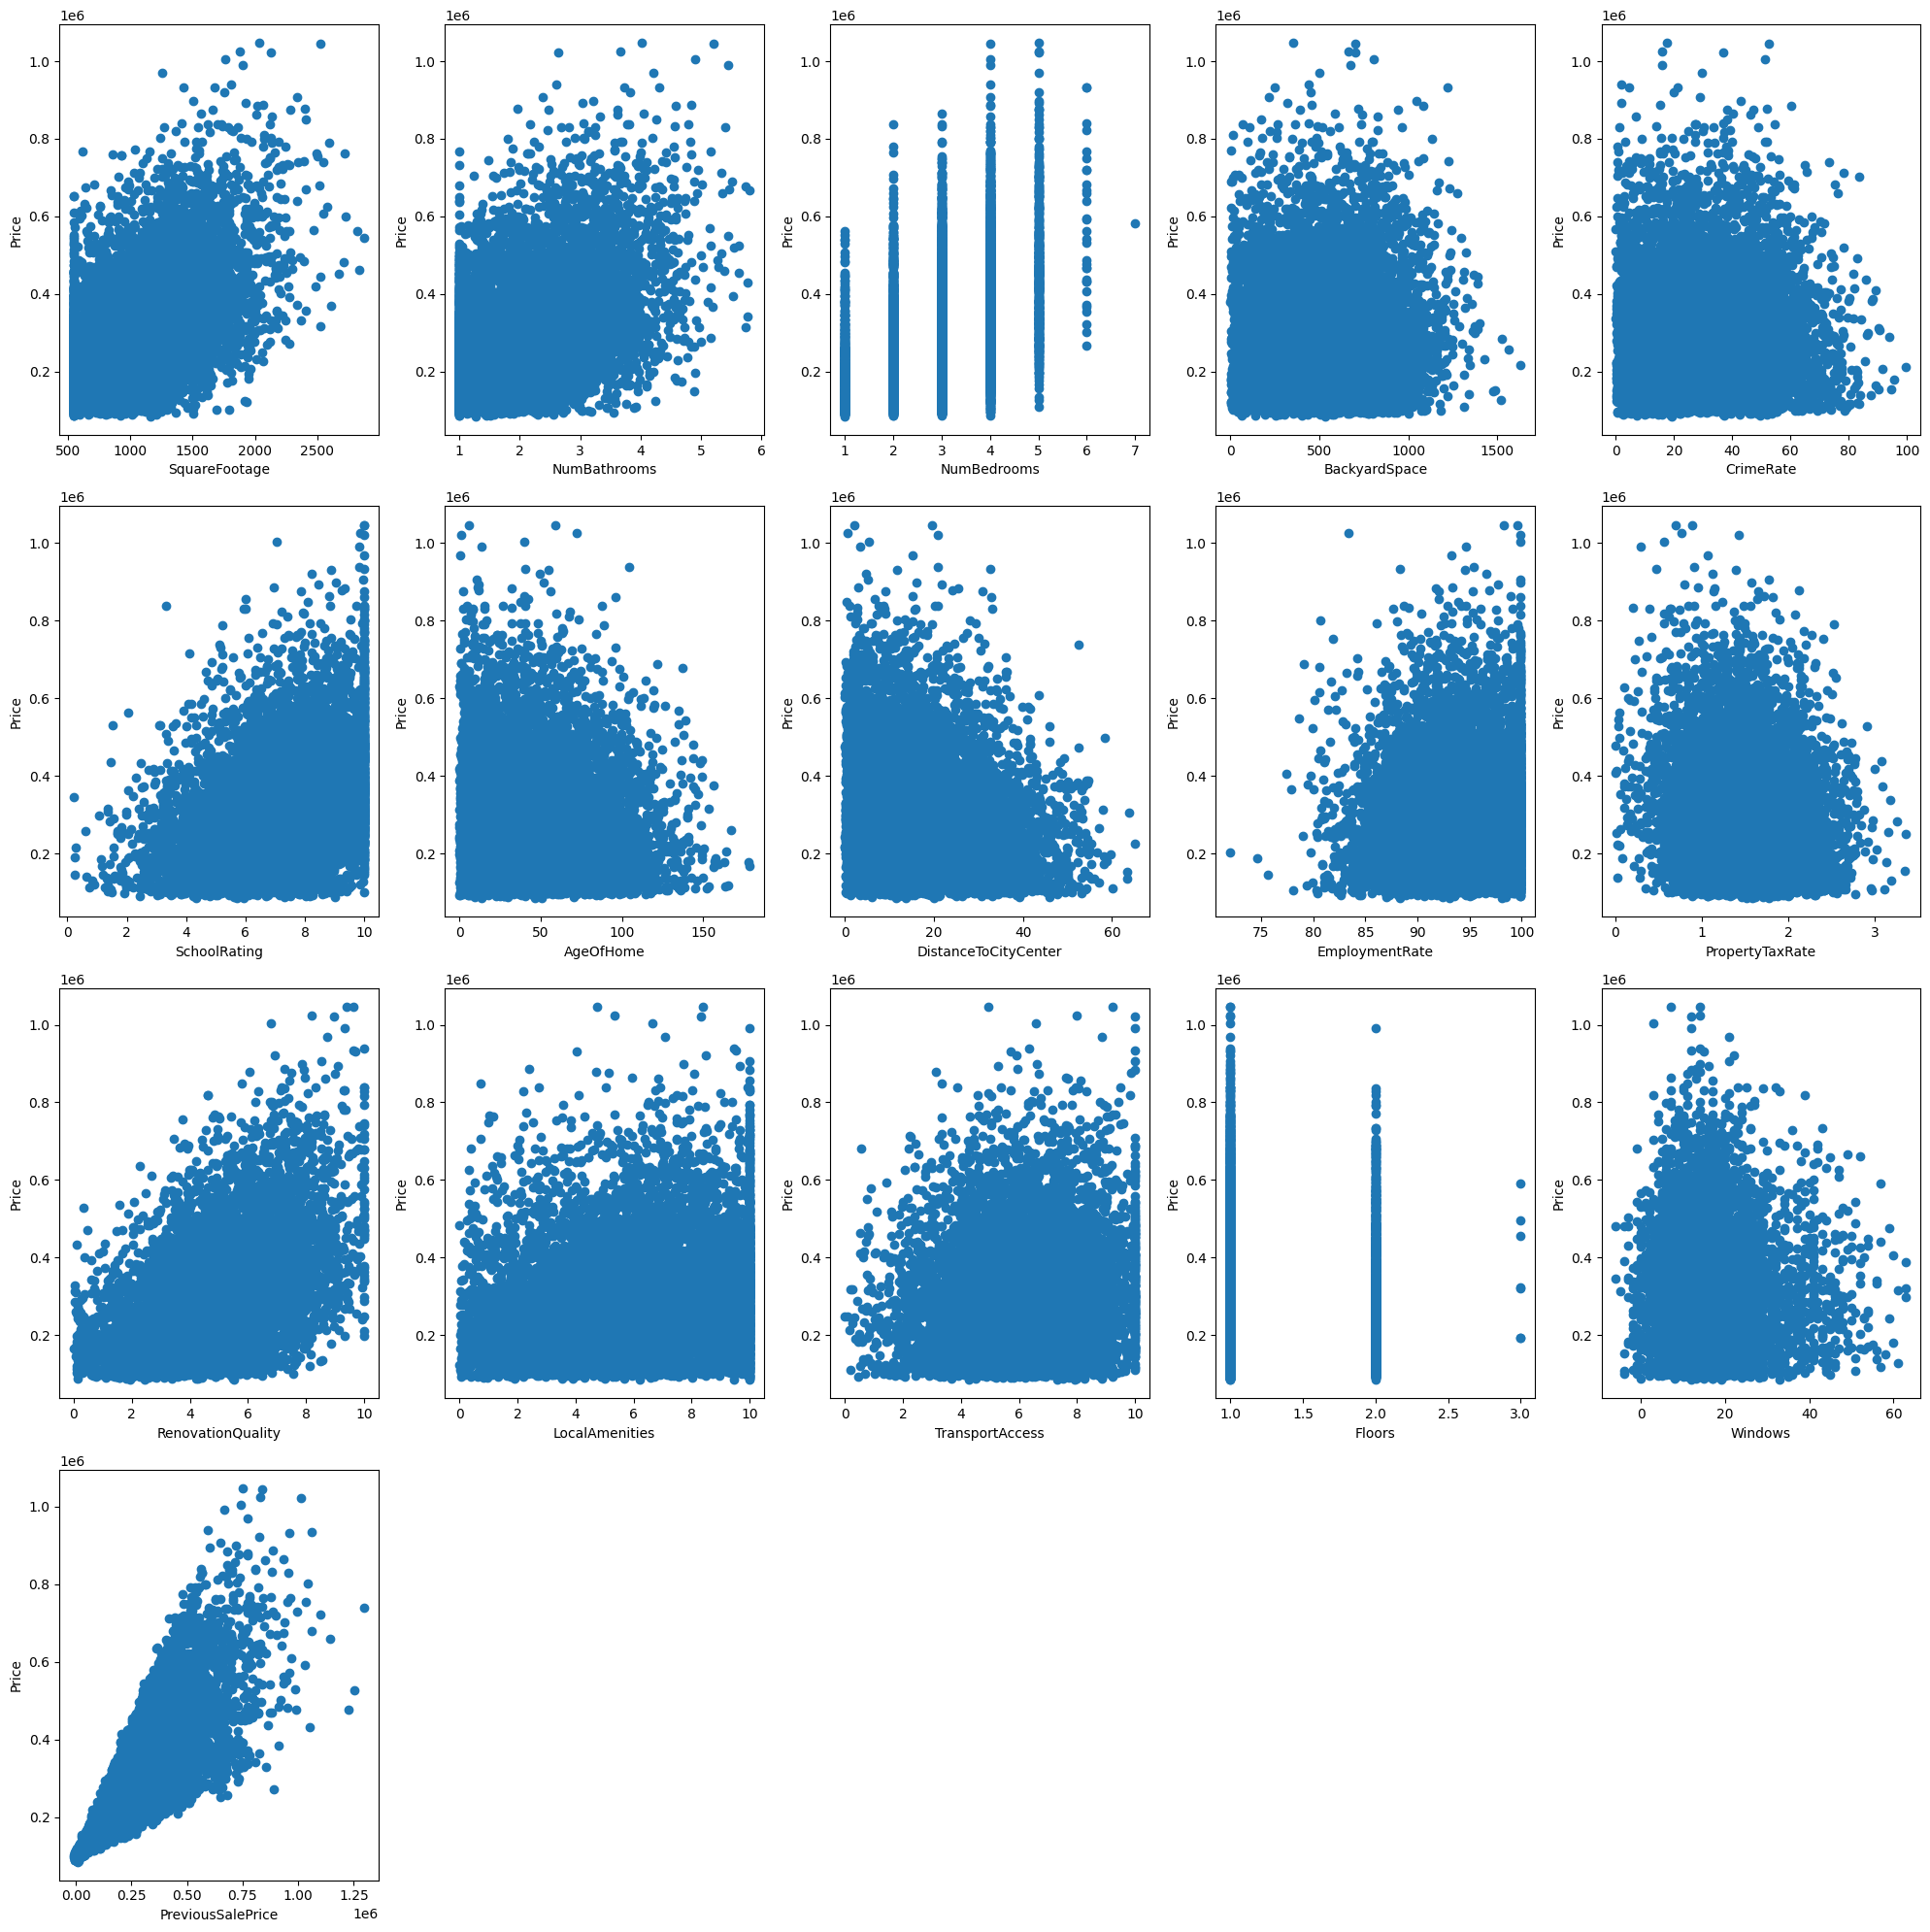

In [20]:
# Logic adapted from GeeksforGeeks (2025e)
# Source: https://www.geeksforgeeks.org/python/plot-multiple-plots-in-matplotlib/

independent_vars = df_num.columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 20))
# converts 2D array into 1D
axes = axes.flatten()

for i, var in enumerate(independent_vars):
    axes[i].scatter(df[var], df['Price'])
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Price')

# Hide plots that are empty
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [21]:
df_cat = df_ind.select_dtypes(exclude='number')
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Fireplace   7000 non-null   object  
 1   HouseColor  7000 non-null   object  
 2   Garage      7000 non-null   object  
 3   IsLuxury    7000 non-null   category
dtypes: category(1), object(3)
memory usage: 171.1+ KB


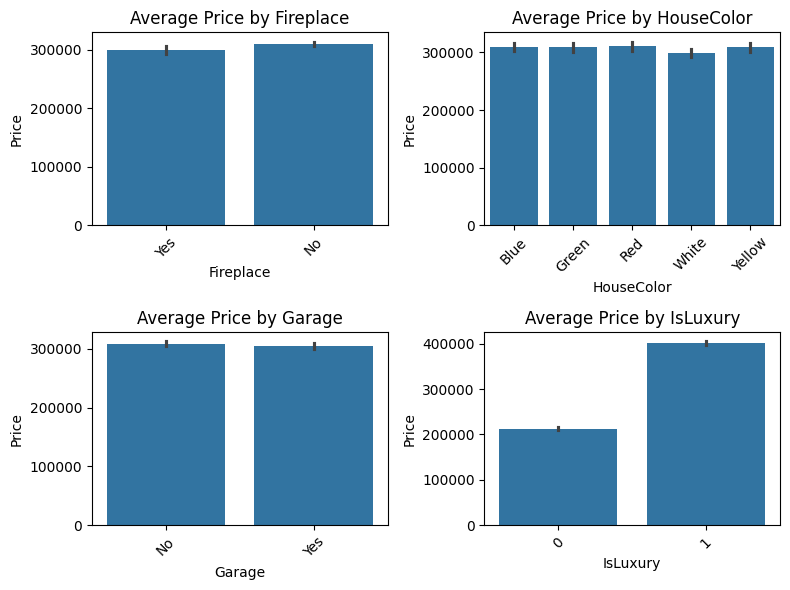

In [22]:
vars = df_cat.columns.to_list()

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for i, var in enumerate(vars):
    sns.barplot(x=var, y='Price', data=df, estimator='mean', ax=axes[i])
    axes[i].set_title(f'Average Price by {var}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide plots that are empty
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Encode Data

In [23]:
# encode the 2 columns
df = pd.get_dummies(df, columns=["Fireplace", "HouseColor", "Garage"], drop_first=True, prefix=["Fireplace", "HouseColor", "Garage"])
# Map values to 1 and 0
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,Floors,Windows,PreviousSalePrice,IsLuxury,Fireplace_Yes,HouseColor_Green,HouseColor_Red,HouseColor_White,HouseColor_Yellow,Garage_Yes
0,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,97.29,1.84,4.93,4.44,4.55,1,13,181861.54230,0,1,0,0,0,0,0
1,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,93.22,0.95,4.08,5.56,6.83,1,17,50042.59757,0,0,1,0,0,0,0
2,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,96.60,1.87,4.26,8.07,8.48,2,34,48400.34440,0,1,1,0,0,0,1
3,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,91.45,1.45,4.45,5.00,6.27,1,14,84594.12145,0,1,0,1,0,0,0
4,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,86.50,1.26,3.36,5.46,6.99,1,21,22934.59654,0,0,0,0,1,0,1


# Splitting the data into testing and training datasets

In [24]:
# Logic adapted from GeeksforGeeks (2025d)
# Source: https://www.geeksforgeeks.org/machine-learning/how-to-do-train-test-split-using-sklearn-in-python/

y= df['Price']
X=df.drop(columns = ['Price'])

# split the data into 80/20
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=1, 
                                   test_size=0.20)

In [25]:
print(X_train.shape)
X_train.to_csv("X_train.csv")

(5600, 23)


In [26]:
print(X_test.shape)
X_test.to_csv("X_test.csv")

(1400, 23)


In [27]:
print(y_train.shape)
y_train.to_csv("y_train.csv")

(5600,)


In [28]:
print(y_test.shape)
y_test.to_csv("y_test.csv")

(1400,)


# Perform Regression Model Before Optimization

In [29]:
# Logic adapted from GeeksforGeeks (2025d)
# Source: https://www.geeksforgeeks.org/data-science/ordinary-least-squares-ols-using-statsmodels/
X_train_original = sm.add_constant(X_train)

lm = sm.OLS(y_train, X_train_original).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     680.4
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:44:53   Log-Likelihood:                -71001.
No. Observations:                5600   AIC:                         1.420e+05
Df Residuals:                    5576   BIC:                         1.422e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.205e+04 

In [30]:
y_ori_train_pred = lm.predict(X_train_original)
MSE = mean_squared_error(y_train, y_ori_train_pred)
print(f"\nTrain MSE: {MSE:.2f}, Train RMSE: {np.sqrt(MSE):.2f}")


Train MSE: 6027533262.44, Train RMSE: 77637.19


In [31]:
X_test_original = sm.add_constant(X_test)

y_ori_test_pred = lm.predict(X_test_original)
MSE = mean_squared_error(y_test, y_ori_test_pred)
print(f"\nTestMSE: {MSE:.2f}, Test RMSE: {np.sqrt(MSE):.2f}")


TestMSE: 5573095452.57, Test RMSE: 74653.17


# Check for independence in Residuals

In [32]:
residuals = lm.resid

dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

Durbin-Watson statistic: 2.020


# Check for Multicollinearity

In [45]:
#create a dataframe containing VIFs
vif = pd.DataFrame()
vif['Features'] = X_train.columns
#shape[1] gets the number of columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
 
print(vif)

                Features     VIF
0                  const  525.52
16     PreviousSalePrice    3.53
1          SquareFootage    1.90
3            NumBedrooms    1.74
11     RenovationQuality    1.68
21      HouseColor_White    1.63
22     HouseColor_Yellow    1.62
19      HouseColor_Green    1.61
20        HouseColor_Red    1.60
6           SchoolRating    1.58
14                Floors    1.54
2           NumBathrooms    1.54
15               Windows    1.54
17              IsLuxury    1.47
12        LocalAmenities    1.35
13       TransportAccess    1.35
8   DistanceToCityCenter    1.09
9         EmploymentRate    1.07
10       PropertyTaxRate    1.06
7              AgeOfHome    1.05
5              CrimeRate    1.05
4          BackyardSpace    1.03
18         Fireplace_Yes    1.00
23            Garage_Yes    1.00


### Remove columns that had a high VIF score

In [34]:
X_train.drop(columns=['EmploymentRate', 'SchoolRating', 'Floors', 'TransportAccess'], inplace=True)

In [35]:
#create a dataframe containing VIFs
vif = pd.DataFrame()
vif['Features'] = X_train.columns
#shape[1] gets the number of columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
 
print(vif) # all under 10-15

                Features    VIF
2            NumBedrooms  12.42
0          SquareFootage  11.05
8      RenovationQuality  10.98
11     PreviousSalePrice  10.67
7        PropertyTaxRate   9.12
1           NumBathrooms   7.82
9         LocalAmenities   5.86
3          BackyardSpace   4.29
10               Windows   4.09
4              CrimeRate   3.90
5              AgeOfHome   3.17
6   DistanceToCityCenter   3.16
12              IsLuxury   2.92
16      HouseColor_White   1.98
14      HouseColor_Green   1.94
17     HouseColor_Yellow   1.93
15        HouseColor_Red   1.92
18            Garage_Yes   1.55
13         Fireplace_Yes   1.34


# Backwards Stepwise Elimination

In [36]:
# Logic adapted from GeeksforGeeks (2025h)
# Source: https://www.geeksforgeeks.org/machine-learning/stepwise-regression-in-python/

# Add constant for intercept
X = sm.add_constant(X_train)

# Set significance level
SL = 0.05

# Initialize list of columns
cols = list(X.columns)

while True:
    model = sm.OLS(y_train, X[cols]).fit()
    pvalues = model.pvalues.iloc[1:]  # exclude constant
    max_pval = pvalues.max()
    if max_pval > SL:
        # Remove the variable with the highest p-value
        excluded = pvalues.idxmax()
        cols.remove(excluded)
        print(f"Removed {excluded} with p-value {max_pval:.4f}")
    else:
        break

Removed Garage_Yes with p-value 0.9809
Removed Windows with p-value 0.8338
Removed HouseColor_Yellow with p-value 0.6834
Removed Fireplace_Yes with p-value 0.3993
Removed CrimeRate with p-value 0.3867
Removed HouseColor_White with p-value 0.2345
Removed HouseColor_Red with p-value 0.3222
Removed AgeOfHome with p-value 0.0924
Removed BackyardSpace with p-value 0.0557


In [37]:
final_model = sm.OLS(y_train, X[cols]).fit()
print("\nFinal model summary:")
print(final_model.summary())


Final model summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     1563.
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:44:54   Log-Likelihood:                -71009.
No. Observations:                5600   AIC:                         1.420e+05
Df Residuals:                    5589   BIC:                         1.421e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const     

In [38]:
y_train_pred = final_model.predict(X[cols])
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print(f"\nTrain MSE: {train_mse:.2f}, Train RMSE: {train_rmse:.2f}")


Train MSE: 6044594453.50, Train RMSE: 77746.99


In [39]:
y_train.mean()

np.float64(308580.86848681606)

In [40]:
(77746.99/308580.86848681606) * 100

25.195013022436193

In [41]:
X = sm.add_constant(X_test)

y_test_pred = final_model.predict(X[cols])
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
print(f"\nTest MSE: {test_mse:.2f}, Test RMSE: {test_rmse:.2f}")


Test MSE: 5555404703.55, Test RMSE: 74534.59


In [42]:
y_test.mean()

np.float64(302086.3868095215)

In [43]:
(74534.59/302086.3868095215) * 100

24.673270049403875